<div style="background:linear-gradient(135deg,#4a044e 0%,#a21caf 55%,#e879f9 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#f5d0fe;font-weight:700;text-transform:uppercase">Chapter 148 · Advanced &amp; Applied Topics</div>
  <div style="font-size:34px;font-weight:900;line-height:1.1;margin:10px 0 6px">NLP &amp; Large Language Models</div>
  <div style="font-size:15px;color:#fae8ff;max-width:740px;line-height:1.6">Models eat numbers; language is not numbers. We walk the ladder: tokens, bag-of-words, TF-IDF, embeddings, then self-attention computed by hand, and finish by implementing perplexity, BLEU and ROUGE from scratch so the metrics stop being magic.</div>
</div>

Run top to bottom. Uses **scikit-learn**, **numpy**, and **matplotlib**. Attention and every evaluation metric are written out explicitly rather than imported.

In [1]:
import numpy as np, pandas as pd, re, math
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import TruncatedSVD
from sklearn.metrics.pairwise import cosine_similarity
plt.rcParams.update({"figure.dpi":110,"axes.grid":True,"grid.alpha":0.25,"font.size":11})
FU, BL, GR, RD = "#a21caf", "#2563eb", "#16a34a", "#dc2626"
BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "nlp-and-large-language-models--product-reviews.xlsx"
try:
    df = pd.read_excel("../../data/" + fn)
except FileNotFoundError:
    df = pd.read_excel(BASE + fn)
print(df.shape); print(df.head(3).to_string())
X = df.review_text.values; y = (df.sentiment == "positive").astype(int).values
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.3, random_state=1, stratify=y)

(800, 3)
  review_id                                                                review_text sentiment
0     R1000                   for the price, arrived on time, fantastic build quality.  positive
1     R1001           would not recommend, shipping was quick, used it for a few days.  negative
2     R1002  exceeded my expectations, used it for a few days, the packaging was fine.  positive


## DEMO 1 &middot; Text to numbers: bag-of-words and TF-IDF
Tokenize, build a vocabulary, and count. Then compare raw counts with TF-IDF weighting on the same classifier.

In [2]:
results = {}
for name, vec in [("bag-of-words", CountVectorizer()), ("TF-IDF", TfidfVectorizer())]:
    A = vec.fit_transform(Xtr); B = vec.transform(Xte)
    clf = LogisticRegression(max_iter=1000).fit(A, ytr)
    p = clf.predict(B)
    results[name] = (accuracy_score(yte, p), f1_score(yte, p))
    print(f"{name:14} accuracy={results[name][0]:.3f}  F1={results[name][1]:.3f}  vocabulary={len(vec.vocabulary_)} words")
    if name == "TF-IDF": tfidf, tclf = vec, clf
print("\nThe two tie here: short, clean reviews with a small vocabulary give TF-IDF nothing to down-weight.")
print("About 8% of the labels are deliberately flipped, so ~93% is the ceiling, not a model weakness.")

bag-of-words   accuracy=0.929  F1=0.931  vocabulary=80 words
TF-IDF         accuracy=0.929  F1=0.931  vocabulary=80 words

The two tie here: short, clean reviews with a small vocabulary give TF-IDF nothing to down-weight.
About 8% of the labels are deliberately flipped, so ~93% is the ceiling, not a model weakness.


## DEMO 2 &middot; Read the model: which words carry the signal?
A linear model on text is interpretable: each word has a coefficient. The extremes should look like sentiment.

strongest POSITIVE words: great, highly, works, this, excellent, build, fantastic, expectations
strongest NEGATIVE words: poor, not, would, waste, of, terrible, experience, right


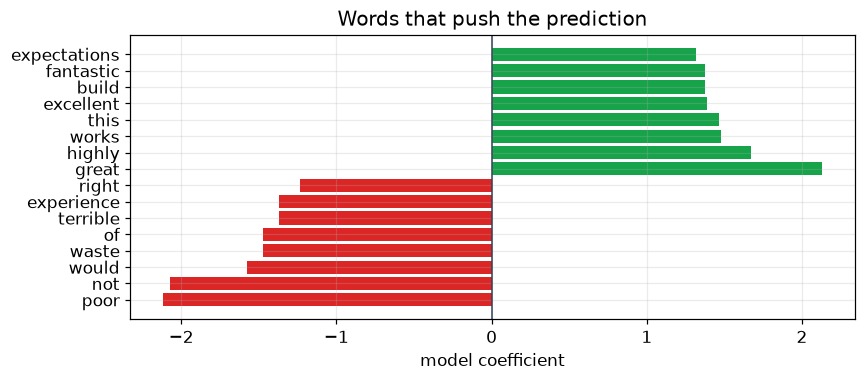

In [3]:
names = np.array(tfidf.get_feature_names_out()); coef = tclf.coef_[0]
top_pos = names[np.argsort(-coef)][:8]; top_neg = names[np.argsort(coef)][:8]
print("strongest POSITIVE words:", ", ".join(top_pos))
print("strongest NEGATIVE words:", ", ".join(top_neg))
fig, ax = plt.subplots(figsize=(8, 3.6))
idx = np.r_[np.argsort(coef)[:8], np.argsort(-coef)[:8]]
ax.barh(names[idx], coef[idx], color=[RD]*8 + [GR]*8)
ax.axvline(0, color="#334155", lw=1); ax.set_xlabel("model coefficient"); ax.set_title("Words that push the prediction")
plt.tight_layout(); plt.show()

## DEMO 3 &middot; Embeddings: meaning as geometry
Bag-of-words treats every word as its own dimension. Reduce the term-document matrix with SVD and words used in similar contexts land near each other, so cosine similarity becomes a meaning score.

Read the output with a pinch of salt: with only 80 distinct words across 800 short reviews, these neighbours are **crude** and partly reflect which words happen to sit in the same canned phrase (so 'terrible' pulls in 'experience'). Real embeddings are trained on billions of tokens, which is what makes their geometry genuinely semantic. The mechanism is identical; only the scale differs.

In [4]:
cv = CountVectorizer(); M = cv.fit_transform(df.review_text).T      # terms x documents
emb = TruncatedSVD(n_components=8, random_state=0).fit_transform(M)  # a dense vector per word
vocab = np.array(cv.get_feature_names_out())
S = cosine_similarity(emb)
def neighbours(word, n=4):
    i = int(np.where(vocab == word)[0][0])
    order = [j for j in np.argsort(-S[i]) if j != i][:n]
    return [(vocab[j], round(float(S[i][j]), 2)) for j in order]
for w in ["great", "terrible", "money"]:
    if w in vocab: print(f"{w:9} -> {neighbours(w)}")

great     -> [('value', 0.98), ('works', 0.93), ('money', 0.91), ('and', 0.84)]
terrible  -> [('experience', 1.0), ('highly', 0.94), ('right', 0.92), ('away', 0.92)]
money     -> [('great', 0.91), ('value', 0.89), ('exactly', 0.86), ('needed', 0.86)]


## DEMO 4 &middot; Self-attention, computed by hand
The heart of a transformer in six lines: score every query against every key, softmax the scores into weights, blend the values. Each row of weights sums to 1.

attention weight matrix (rows sum to 1):
          The  animal  crossed    it
The      0.35    0.22     0.23  0.20
animal   0.55    0.24     0.08  0.13
crossed  0.32    0.13     0.21  0.34
it       0.16    0.20     0.12  0.52

row sums: [1. 1. 1. 1.]


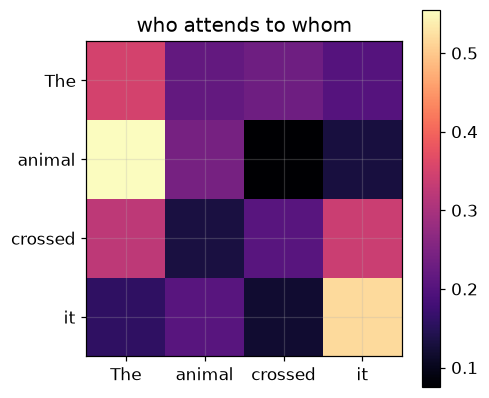

In [5]:
rng = np.random.default_rng(0)
tokens = ["The", "animal", "crossed", "it"]
d = 4
Q = rng.normal(size=(len(tokens), d)); K = rng.normal(size=(len(tokens), d)); V = rng.normal(size=(len(tokens), d))
scores = Q @ K.T / np.sqrt(d)                       # compare each query to every key
scores = scores - scores.max(axis=1, keepdims=True) # stable softmax
W = np.exp(scores); W = W / W.sum(axis=1, keepdims=True)
out = W @ V                                          # weighted blend of values
print("attention weight matrix (rows sum to 1):")
print(pd.DataFrame(W.round(2), index=tokens, columns=tokens).to_string())
print("\nrow sums:", W.sum(axis=1).round(3))
fig, ax = plt.subplots(figsize=(4.6, 4))
im = ax.imshow(W, cmap="magma"); ax.set_xticks(range(len(tokens)), tokens); ax.set_yticks(range(len(tokens)), tokens)
ax.set_title("who attends to whom"); plt.colorbar(im, ax=ax); plt.tight_layout(); plt.show()

## DEMO 5 &middot; Perplexity: how surprised is the model?
Train unigram and bigram language models on the reviews and score held-out text. Perplexity is exp(mean negative log probability), loosely 'how many words is it choosing among'. Context should cut it sharply.

In [6]:
def toks(s): return ["<s>"] + re.findall(r"[a-z']+", s.lower()) + ["</s>"]
train_toks = [toks(s) for s in Xtr]; test_toks = [toks(s) for s in Xte]
uni = Counter(); bi = Counter()
for t in train_toks:
    uni.update(t); bi.update(zip(t[:-1], t[1:]))
V = len(uni); k = 0.5; total = sum(uni.values())
lp_u = sum(math.log((uni[w] + k) / (total + k*V)) for t in test_toks for w in t[1:])
n_u  = sum(len(t) - 1 for t in test_toks)
lp_b, n_b = 0.0, 0
for t in test_toks:
    for a, b in zip(t[:-1], t[1:]):
        lp_b += math.log((bi[(a, b)] + k) / (uni[a] + k*V)); n_b += 1
print(f"unigram perplexity = {math.exp(-lp_u/n_u):6.1f}   (no context)")
print(f"bigram  perplexity = {math.exp(-lp_b/n_b):6.1f}   (one word of context)")
print("\nKnowing just the previous word makes the model far less surprised. That is the whole premise of language modeling.")

unigram perplexity =   64.7   (no context)
bigram  perplexity =    5.1   (one word of context)

Knowing just the previous word makes the model far less surprised. That is the whole premise of language modeling.


## DEMO 6 &middot; BLEU and ROUGE from scratch
Both compare n-grams to a reference. BLEU leans on precision (what you produced that the reference has); ROUGE leans on recall (how much of the reference you covered). Neither understands meaning.

In [7]:
ref = "the cat sat on the mat".split()
cand = "the cat sat on a mat".split()
def ngrams(s, n): return Counter(tuple(s[i:i+n]) for i in range(len(s)-n+1))
def precision(c, r, n):
    cn, rn = ngrams(c, n), ngrams(r, n)
    return sum(min(v, rn[g]) for g, v in cn.items()) / max(sum(cn.values()), 1)
def recall(c, r, n):
    cn, rn = ngrams(c, n), ngrams(r, n)
    return sum(min(v, cn[g]) for g, v in rn.items()) / max(sum(rn.values()), 1)
p1, p2 = precision(cand, ref, 1), precision(cand, ref, 2)
print(f"reference: {' '.join(ref)}")
print(f"candidate: {' '.join(cand)}")
print(f"\n1-gram precision = {p1:.2f},  2-gram precision = {p2:.2f}")
print(f"BLEU-style score (geometric mean)  = {math.sqrt(p1*p2):.2f}")
print(f"ROUGE-1 recall                     = {recall(cand, ref, 1):.2f}")
print("\nSwapping 'the' for 'a' barely changes the meaning but visibly dents the score:")
print("that is exactly why BERTScore and human evaluation exist.")

reference: the cat sat on the mat
candidate: the cat sat on a mat

1-gram precision = 0.83,  2-gram precision = 0.60
BLEU-style score (geometric mean)  = 0.71
ROUGE-1 recall                     = 0.83

Swapping 'the' for 'a' barely changes the meaning but visibly dents the score:
that is exactly why BERTScore and human evaluation exist.


### Wrap-up
The ladder in one notebook: tokens to counts to TF-IDF (both hitting **92.9%**, capped by 8% label noise), to embeddings where cosine similarity measures meaning, to **self-attention** computed by hand, the operation a transformer stacks dozens of times. Then the measuring stick: context cut perplexity from about **65 to 5**, and BLEU/ROUGE showed how word-overlap metrics reward matching tokens rather than matching meaning. Next in Part XXIV: **Big Data & Scaling**.